In [152]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [153]:
df = pd.read_csv('./data/big_mart_sales.csv')
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [155]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [156]:
# drop idetifier column
df = df.drop(columns=['Item_Identifier', 'Outlet_Identifier'])


In [157]:
target_col = 'Item_Outlet_Sales'

In [158]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols = numerical_cols.drop('Item_Outlet_Sales').tolist()
numerical_cols

['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

In [159]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['Item_Fat_Content',
 'Item_Type',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

Data Cleaning and Checking of Nulls

In [160]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [161]:
# check nulls
df.isnull().sum()

Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [162]:
# import imputer from sklearn
from sklearn.impute import SimpleImputer
# create an imputer object with the strategy of mean
numerical_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')
# fit the imputer on the numerical columns and transform the data

df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])

df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

In [163]:
# check nulls again to confirm that they have been imputed
df.isnull().sum()

Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [164]:
df.describe()
# use describbe to get a quick overview of the numerical columns, and to check for any potential outliers or anomalies in the data

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.00000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.81342,0.066132,140.992782,1997.831867,2181.288914
std,4.22724,0.051598,62.275067,8.371760,1706.499616
min,4.55500,0.000000,31.290000,1985.000000,33.290000
25%,9.31000,0.026989,93.826500,1987.000000,834.247400
50%,12.60000,0.053931,143.012800,1999.000000,1794.331000
75%,16.00000,0.094585,185.643700,2004.000000,3101.296400
max,21.35000,0.328391,266.888400,2009.000000,13086.964800


<small>
From the inference above it seems to show that for the item weight the mean and median are near, this suggest that data is not skewed. 
 <br> <br>
For the Item_Visibility it shows that the mean is slightly skewde to the right which may indicate some sort of outlier in the higher values
 <br> <br>
 For the Item_MRP, the mean and the median are roughly the same with  the mean lower (skwewed to left). This may indicate that there are some outliers in the lower values but nothing extreme or significant
  <br> <br>
  For the Outlet establishment year it shows here that the mean is 1997. Considering that years are less continuous in range. The items average year must've been around 1997. Considering the min and max, this data was from 1985-2009
   <br> <br>
   For the <b>target column: Item_Outlet_Sales </b>, it seems that the mean is higher than the median indicating a histogram that is skewed to the right. 
</small>

In [165]:
for col in categorical_cols:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("\n")
    
    # This is so that we can easily see what encoding type fits the columns

Unique values in column 'Item_Fat_Content':
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']


Unique values in column 'Item_Type':
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']


Unique values in column 'Outlet_Size':
['Medium' 'High' 'Small']


Unique values in column 'Outlet_Location_Type':
['Tier 1' 'Tier 3' 'Tier 2']


Unique values in column 'Outlet_Type':
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']




In [166]:
df[numerical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Visibility            8523 non-null   float64
 2   Item_MRP                   8523 non-null   float64
 3   Outlet_Establishment_Year  8523 non-null   float64
dtypes: float64(4)
memory usage: 266.5 KB


Exploratory Data Analysis 

In [167]:
# helper function for interpreting correlation results
def interpret_correlation(corr_value):
    if corr_value > 0.7:
        return "strong positive correlation"
    elif corr_value > 0.3:
        return "moderate positive correlation"
    elif corr_value > 0:
        return "weak positive correlation"
    elif corr_value < -0.7:
        return "strong negative correlation"
    elif corr_value < -0.3:
        return "moderate negative correlation"
    elif corr_value < 0:
        return "weak negative correlation"
    else:
        return "no correlation"

In [168]:
# helper function to interpret level of skewness
def interpret_skewness(skew_value):
    if skew_value > 1:
        return "highly positively skewed"
    elif skew_value > 0.5:
        return "moderately positively skewed"
    elif skew_value > 0:
        return "slightly positively skewed"
    elif skew_value < -1:
        return "highly negatively skewed"
    elif skew_value < -0.5:
        return "moderately negatively skewed"
    elif skew_value < 0:
        return "slightly negatively skewed"
    else:
        return "symmetrical distribution"

In [169]:
num_w_target = numerical_cols.append(target_col)

Correlation matrix:


<Axes: >

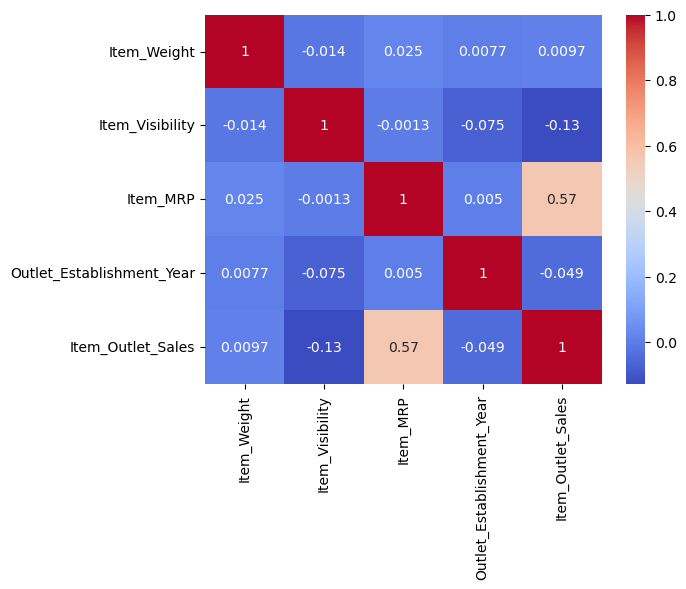

In [170]:
# we use a heatmap to visualize correlation
# note that we cannot treat correlation as causation, but it can give us insights into the relationships between the numerical features and the target variable
print("Correlation matrix:")
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')

<small>From the results above it seems to suggest that out of the numerical columns the one with the highest correlation standing at 0.57 is the <b>Item_MRP</b>. The correlation is moderately significant<br><br> Listed below are the interpreted correlations for each in relation to the target column</small> 

In [171]:
for col in numerical_cols: 
    print(f"Correlation between '{col}' and '{target_col}': {df[col].corr(df[target_col])} ({interpret_correlation(df[col].corr(df[target_col]))})")

Correlation between 'Item_Weight' and 'Item_Outlet_Sales': 0.00969287582663097 (weak positive correlation)
Correlation between 'Item_Visibility' and 'Item_Outlet_Sales': -0.1286246122207703 (weak negative correlation)
Correlation between 'Item_MRP' and 'Item_Outlet_Sales': 0.5675744466569194 (moderate positive correlation)
Correlation between 'Outlet_Establishment_Year' and 'Item_Outlet_Sales': -0.04913497044082087 (weak negative correlation)
Correlation between 'Item_Outlet_Sales' and 'Item_Outlet_Sales': 1.0 (strong positive correlation)


Item_MRP vs Item_Outlet_Sales

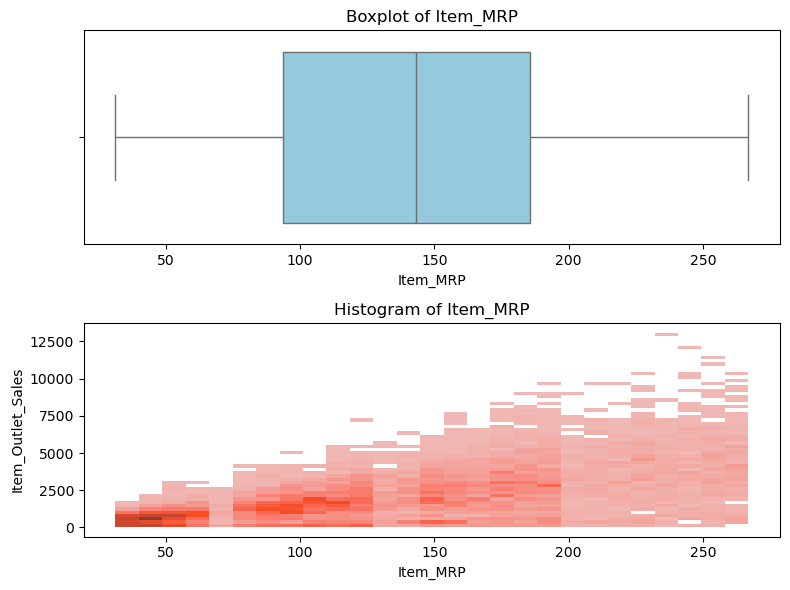

In [184]:

scrutinized_col = "Item_MRP"
target_col = "Item_Outlet_Sales"
category_col = "Outlet_Type"

# Create a figure with 2 rows, 1 column
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

# Top: Boxplot
sns.boxplot(data=df, x=scrutinized_col, ax=axes[0], color="skyblue")
axes[0].set_title(f"Boxplot of {scrutinized_col}")

# Bottom: Histogram
sns.histplot(data=df, x=scrutinized_col, y=target_col, ax=axes[1], kde=True, color="salmon")
axes[1].set_title(f"Histogram of {scrutinized_col}")

plt.tight_layout()
plt.show()


In [185]:
print(f"Skewness of '{scrutinized_col}': {df[scrutinized_col].skew()} ({interpret_skewness(df[scrutinized_col].skew())})")

Skewness of 'Item_MRP': 0.1272022683110526 (slightly positively skewed)


<small> based on the results above there is actually a very clear correlation that when Item_MRP is up then Item_Outlet_sales also go up. With how the histogram distribution looks like, it might be best to try and use a scatter plot to better understand this </small>

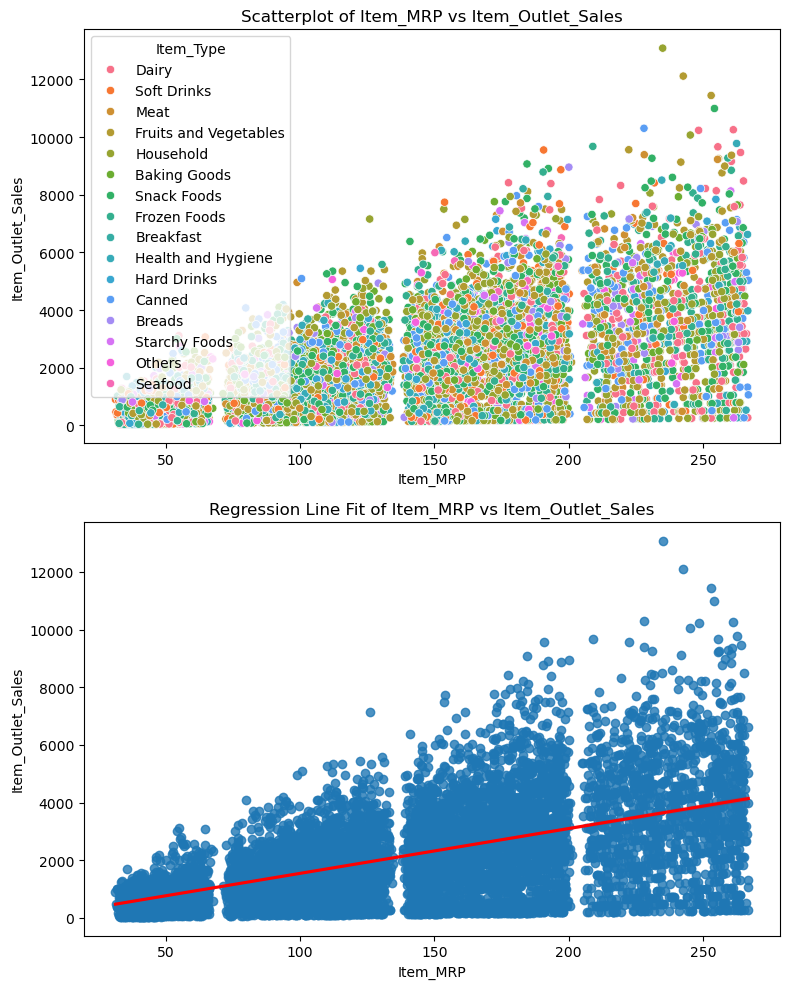

In [189]:

# Create a figure with 2 rows, 1 column
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))

# Top: Scatterplot
sns.scatterplot(data=df, x=scrutinized_col, y=target_col, ax=axes[0], hue='Item_Type')
axes[0].set_title(f"Scatterplot of {scrutinized_col} vs {target_col}")


# Bottom: Regression line plot (scatter + fitted line)
sns.regplot(data=df, x=scrutinized_col, y=target_col, ax=axes[1], scatter=True, line_kws={"color":"red"})
axes[1].set_title(f"Regression Line Fit of {scrutinized_col} vs {target_col}")

plt.tight_layout()
plt.show()


<small> Here we can see that Item Type actually does not have any correlation to the outlet sales as it all over the place. We could try again to see the relationship with other categorical columns to see how the data is scattered </small>

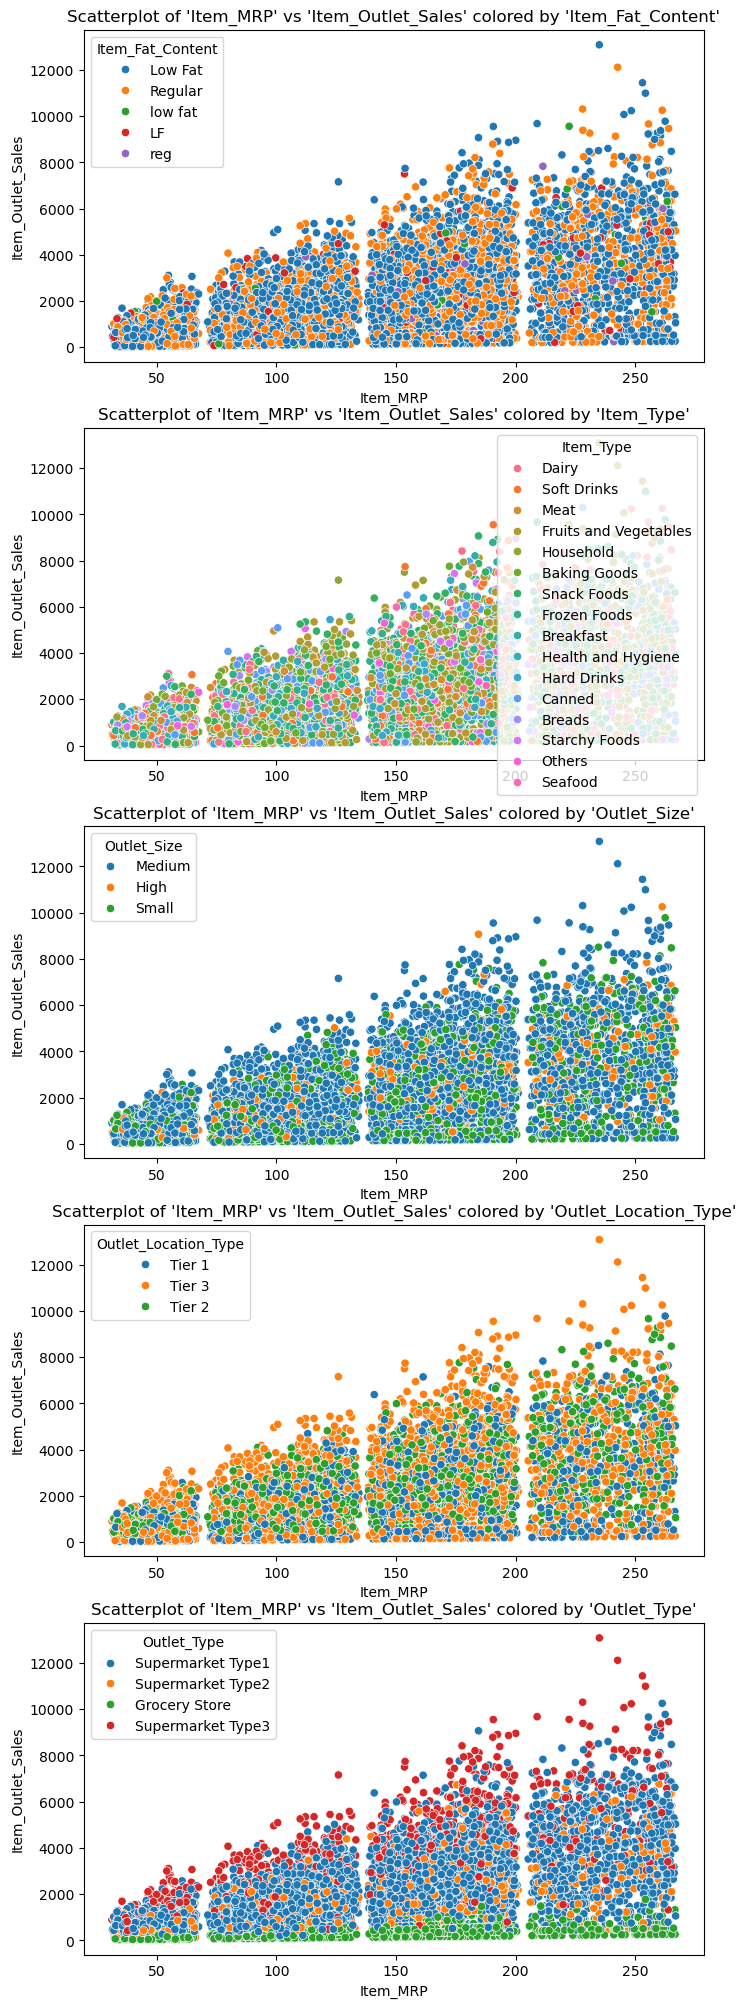

In [193]:
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(8, 5 * len(categorical_cols)))
for i, col in enumerate(categorical_cols):
    axes[i].set_title(f"Scatterplot of '{scrutinized_col}' vs '{target_col}' colored by '{col}'")
    sns.scatterplot(data=df, x=scrutinized_col, y=target_col, ax=axes[i], hue=col)

<small>Based off the plot above, most of the categorical column do not have defined clusters with the exception of one column which is the <b>Outlet_Type</b>. It seems that there's a significance as well can clearly see that SuperMarket type three is on the 'outer corner' that is componses of higher values for outlet sales overall. Meanwhile, we have the grocery store which comprieses of mostly low values. SuperMarket Type2 and SuperMarket Type1 seem to 'fall in the middle range' creating a combined cluster <br><br>
- <b>Cluster 1 Reds High Values 
- Insignificant Cluster 2 which ar the oranges and blue 
- Cluster 3 which encompasses the Green at low values

<small>We can try to furthur the analysis by converting the categorical columns into numerical data to check correlations</small>

Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Encode categoricals with one-hot and impute missing entries
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_transformer


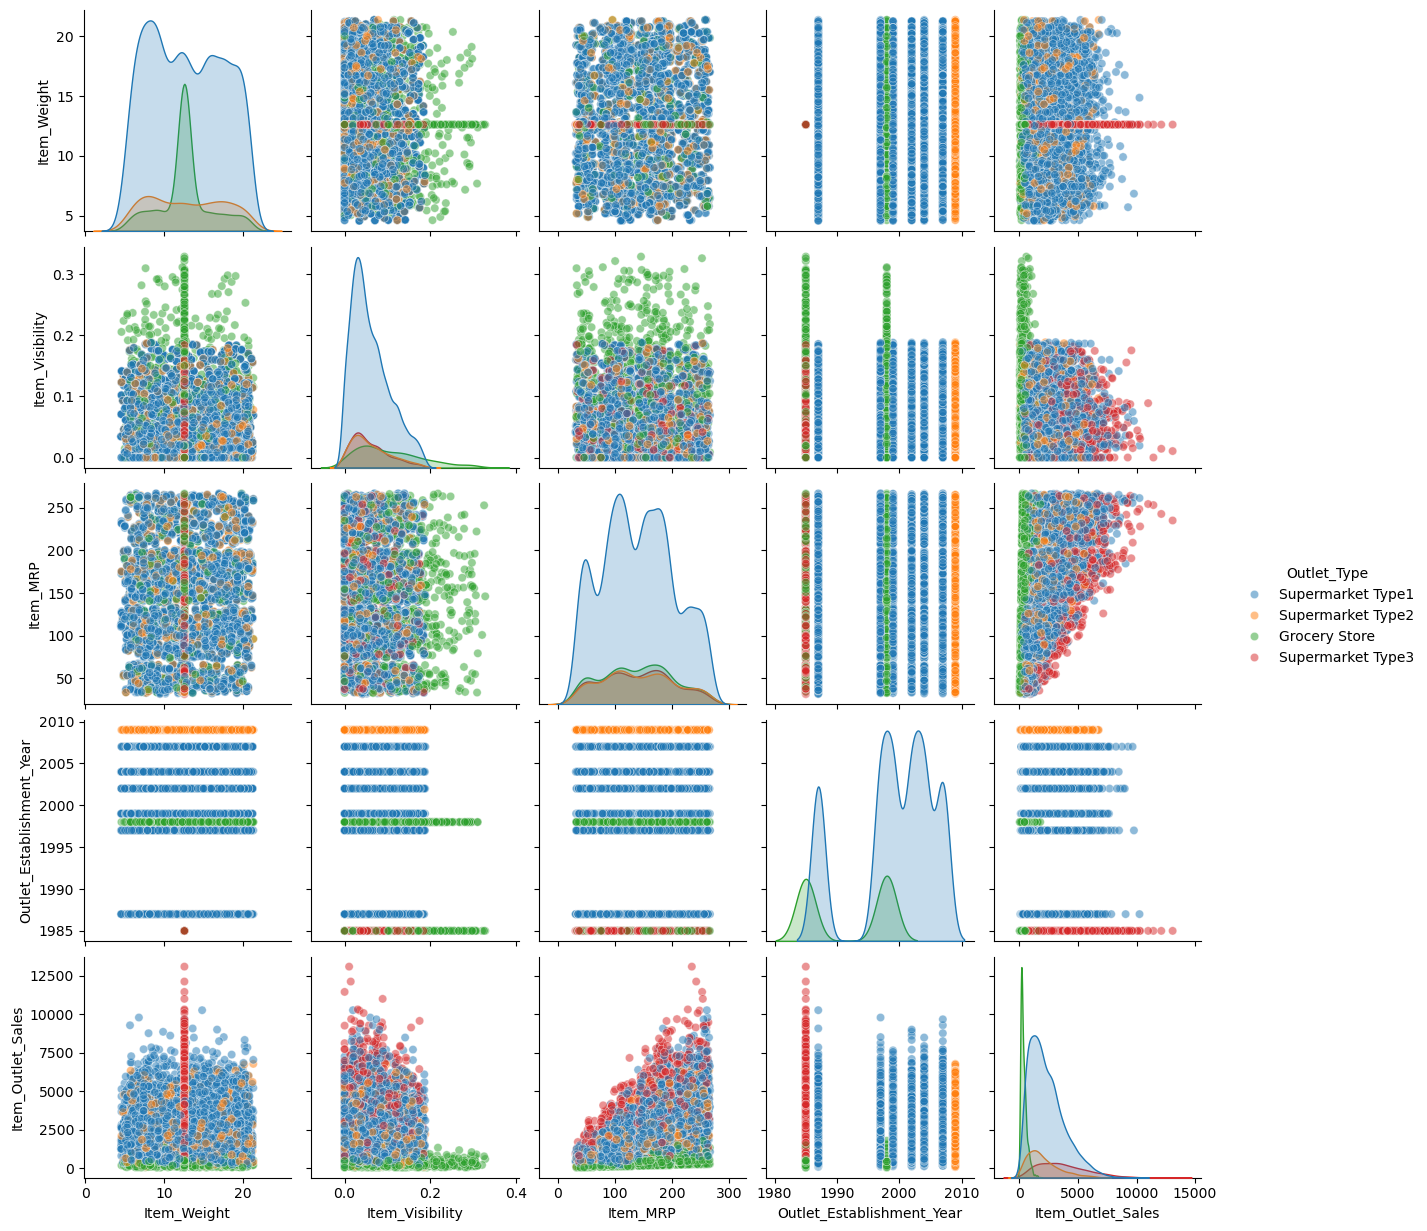

In [203]:
sns.pairplot(data=df, vars=df[numerical_cols], diag_kind='kde', plot_kws={'alpha':0.5}, hue='Outlet_Type')

plt.show()

Feature Engineering

In [ ]:
# Simple feature engineering to expose useful signals
current_year = 2026

df_fe = df.copy()
df_fe['Outlet_Age'] = current_year - df_fe['Outlet_Establishment_Year']
df_fe['Visibility_Percent'] = df_fe['Item_Visibility'] * 100
df_fe['Log_MRP'] = np.log1p(df_fe['Item_MRP'])

numerical_cols_fe = numerical_cols + ['Outlet_Age', 'Visibility_Percent', 'Log_MRP']
df_fe.head()


Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols_fe),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

preprocessor


Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


Fitting

In [ ]:
from sklearn.ensemble import RandomForestRegressor

reg_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)


Hyper Parameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'model__n_estimators': [150, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt']
}

search = RandomizedSearchCV(
    reg_model,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_reg = search.best_estimator_
search.best_params_


Computing Loss using RSME (or other metrics)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

best_pred = best_reg.predict(X_test)
rmse = mean_squared_error(y_test, best_pred, squared=False)
r2 = r2_score(y_test, best_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R^2: {r2:.3f}")


Metrics Evaluation

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Bin sales into two classes for a simple imbalance-aware classifier
sales_threshold = y.median()
df_fe['Sales_Level'] = np.where(df_fe[target_col] >= sales_threshold, 'high', 'low')

X_cls = df_fe.drop(columns=[target_col, 'Sales_Level'])
y_cls = df_fe['Sales_Level']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = ImbPipeline(
    steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=500))
    ]
)

clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

cm = confusion_matrix(y_test_c, y_pred_c, labels=clf.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot(
    cmap='Blues', values_format='d'
)
plt.show()

print(classification_report(y_test_c, y_pred_c))


Conclusion

- Regression pipeline with feature engineering, preprocessing, and a tuned RandomForestRegressor; inspect the printed RMSE and R^2 for hold-out performance.
- Classification check (high vs. low sales) uses the same preprocessing, SMOTE to balance, and logistic regression; review the confusion matrix and classification report above for class-level performance.
- If metrics are unsatisfactory, consider deeper hyperparameter sweeps or gradient boosting models and revisit feature engineering (e.g., item category groupings).
